# Phase 5: Coverage error, and does a better score move the frontier?

CPU only. Attach the Phase 1 notebook output.

In [1]:
import glob, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

p=[h for h in glob.glob("/kaggle/input/**/*.npz",recursive=True) if h.endswith("logits.npz")][0]
d=np.load(p); SEEDS=[0,1,2]
CORR=["gaussian_noise","shot_noise","impulse_noise","defocus_blur","glass_blur",
      "motion_blur","zoom_blur","snow","frost","fog","brightness","contrast",
      "elastic_transform","pixelate","jpeg_compression"]
CELLS=[("test",0)]+[(c_,s) for s in range(1,6) for c_ in CORR]
TG=0.05; TOL=1e-9

def softmax(z,T=1.0):
    z=z.astype(np.float64)/T; z-=z.max(1,keepdims=True); e=np.exp(z); return e/e.sum(1,keepdims=True)
def nll(p,y): return -np.log(np.clip(p[np.arange(len(y)),y],1e-12,None)).mean()
def ep(m,T): return np.mean([softmax(x,T) for x in m],0)

TE=minimize_scalar(lambda t: nll(ep([d[f"val_{s}"] for s in SEEDS],t),d["y_val"]),
                   bounds=(.5,10),method="bounded").x
PVAL=ep([d[f"val_{s}"] for s in SEEDS],TE); YVAL=d["y_val"]

LOGITS={}; P={}
for k,s in CELLS:
    key="test" if k=="test" else f"{k}_{s}"
    LOGITS[(k,s)]=[d[f"{key}_{sd}"] for sd in SEEDS]
    P[(k,s)]=(ep(LOGITS[(k,s)],TE), d["y_test"] if k=="test" else d["y_corr"])
print("ready")

ready


## 1. Correction to the framing

All five selectors in Phase 4 accept in the same order, by ensemble max
probability. They differ only in where they stop. So they all sit on the *same*
risk versus coverage curve by construction, and comparing their realised risks
head to head conflates two things.

The honest single metric is therefore **coverage error**: the coverage a method
chose minus the coverage the oracle needed to hit the target. Positive means the
method accepted too much.

In [2]:
def rc_curve(pr,y):
    """Returns coverage grid and oracle risk at each coverage."""
    conf=pr.max(1); o=np.argsort(-conf)
    risk=1-np.cumsum(pr.argmax(1)[o]==y[o])/np.arange(1,len(o)+1)
    return np.arange(1,len(o)+1)/len(o), risk, conf[o]

def cov_for_target(pr,y,target):
    cov,risk,_=rc_curve(pr,y); ok=np.where(risk<=target+TOL)[0]
    return 0.0 if len(ok)==0 else cov[ok[-1]]

def cov_of_thr(pr,thr): return (pr.max(1)>=thr).mean()

In [3]:
# reuse Phase 4 selectors
def _pick(conf,est,target):
    ok=np.where(est<=target+TOL)[0]
    return 1.0 if len(ok)==0 else np.sort(conf)[::-1][ok[-1]]
def thr_oracle(pr,y,t):
    cov,risk,cs=rc_curve(pr,y); ok=np.where(risk<=t+TOL)[0]
    return 1.0 if len(ok)==0 else cs[ok[-1]]
def thr_meanconf(pr,t):
    conf=pr.max(1); o=np.argsort(-conf)
    return _pick(conf,np.cumsum(1-conf[o])/np.arange(1,len(o)+1),t)
NEGENT=lambda pr:(pr*np.log(np.clip(pr,1e-12,None))).sum(1)
CV=PVAL.argmax(1)==YVAL
CUT_MC=np.quantile(PVAL.max(1),1-CV.mean()); CUT_NE=np.quantile(NEGENT(PVAL),1-CV.mean())
def thr_atc(pr,t,mode="NE"):
    conf=pr.max(1); s=conf if mode=="MC" else NEGENT(pr); cut=CUT_MC if mode=="MC" else CUT_NE
    o=np.argsort(-conf)
    return _pick(conf,np.cumsum(s[o]<cut)/np.arange(1,len(o)+1),t)
THR_CLEAN=thr_oracle(PVAL,YVAL,TG)

M={"clean-transfer":lambda pr,y: THR_CLEAN,
   "mean-conf":     lambda pr,y: thr_meanconf(pr,TG),
   "ATC-MC":        lambda pr,y: thr_atc(pr,TG,"MC"),
   "ATC-NE":        lambda pr,y: thr_atc(pr,TG,"NE")}

print("COVERAGE ERROR  (chosen minus oracle; 0 = perfect, + = accepted too much)")
print(f"{'method':>15} "+" ".join(f"{s:>7}" for s in range(6)))
for n,fn in M.items():
    row=[]
    for sev in range(6):
        ks=[("test",0)] if sev==0 else [(c_,sev) for c_ in CORR]
        row.append(np.mean([cov_of_thr(P[k][0],fn(*P[k]))-cov_for_target(*P[k],TG) for k in ks]))
    print(f"{n:>15} "+" ".join(f"{v:>+7.3f}" for v in row))

COVERAGE ERROR  (chosen minus oracle; 0 = perfect, + = accepted too much)
         method       0       1       2       3       4       5
 clean-transfer  +0.000  +0.166  +0.302  +0.413  +0.538  +0.731
      mean-conf  +0.000  +0.057  +0.113  +0.143  +0.174  +0.227
         ATC-MC  +0.000  +0.098  +0.188  +0.249  +0.313  +0.415
         ATC-NE  +0.000  +0.076  +0.146  +0.191  +0.239  +0.311


## 2. Does a different score move the frontier itself?

Coverage error measures the stopping rule. This measures the *ordering*. If a
better score separates correct from incorrect predictions more cleanly, the whole
curve drops and every method benefits.

AURC is the area under the risk versus coverage curve. Lower is better.

In [4]:
def scores(key):
    pr,y=P[key]; L=LOGITS[key]
    ps=[softmax(m,TE) for m in L]; st=np.stack(ps)
    srt=np.sort(pr,1)
    return {"max-prob":  pr.max(1),
            "margin":    srt[:,-1]-srt[:,-2],
            "neg-entropy":NEGENT(pr),
            "ens-agree": -st.var(0).sum(1)}, pr.argmax(1)==y

def aurc(score,correct):
    o=np.argsort(-score)
    return (1-np.cumsum(correct[o])/np.arange(1,len(o)+1)).mean()

names=["max-prob","margin","neg-entropy","ens-agree"]
print("AURC x1000 (lower = better ordering)")
print(f"{'score':>13} "+" ".join(f"{s:>7}" for s in range(6)))
for nm in names:
    row=[]
    for sev in range(6):
        ks=[("test",0)] if sev==0 else [(c_,sev) for c_ in CORR]
        row.append(np.mean([aurc(scores(k)[0][nm],scores(k)[1]) for k in ks])*1000)
    print(f"{nm:>13} "+" ".join(f"{v:>7.1f}" for v in row))

AURC x1000 (lower = better ordering)
        score       0       1       2       3       4       5
     max-prob     4.4    32.1    57.1    96.3   151.3   255.6
       margin     4.4    32.3    57.6    97.3   152.9   257.6
  neg-entropy     4.5    32.3    57.3    96.2   150.8   254.7
    ens-agree     4.8    34.8    61.8   103.3   161.0   269.1


## 3. Achievable coverage under the best score

If one score wins on AURC, redo the oracle coverage with it. That tells you the
best coverage anyone could have at 5% risk.

In [5]:
BEST="margin"   # change to whichever wins section 2
def cov_for_target_score(key,target,nm):
    sc,corr=scores(key); s=sc[nm]; o=np.argsort(-s)
    risk=1-np.cumsum(corr[o])/np.arange(1,len(o)+1)
    ok=np.where(risk<=target+TOL)[0]
    return 0.0 if len(ok)==0 else (ok[-1]+1)/len(o)

print(f"{'sev':>3} {'cov @ max-prob':>15} {'cov @ '+BEST:>15}")
for sev in range(6):
    ks=[("test",0)] if sev==0 else [(c_,sev) for c_ in CORR]
    a=np.mean([cov_for_target_score(k,TG,"max-prob") for k in ks])
    b=np.mean([cov_for_target_score(k,TG,BEST) for k in ks])
    print(f"{sev:>3} {a:>15.3f} {b:>15.3f}")

sev  cov @ max-prob    cov @ margin
  0           1.000           1.000
  1           0.833           0.832
  2           0.696           0.695
  3           0.584           0.583
  4           0.458           0.456
  5           0.264           0.264


## 4. Plot for the paper

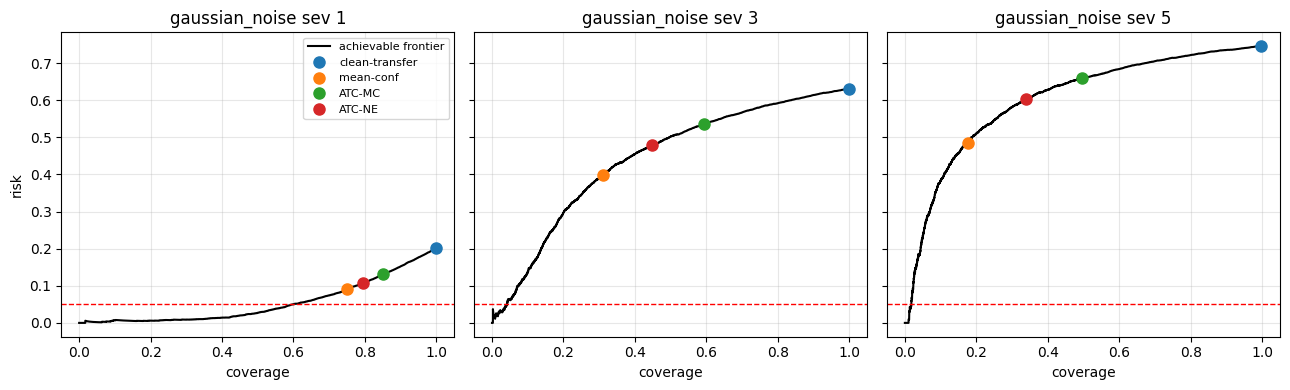

In [6]:
fig,ax=plt.subplots(1,3,figsize=(13,4),sharey=True)
for j,sev in enumerate([1,3,5]):
    k=("gaussian_noise",sev); pr,y=P[k]
    cov,risk,_=rc_curve(pr,y)
    ax[j].plot(cov,risk,c="k",lw=1.5,label="achievable frontier")
    for n,fn in M.items():
        t=fn(pr,y); cv=cov_of_thr(pr,t); r=risk[max(int(cv*len(cov))-1,0)]
        ax[j].plot(cv,r,"o",ms=8,label=n)
    ax[j].axhline(TG,ls="--",c="r",lw=1)
    ax[j].set_title(f"gaussian_noise sev {sev}"); ax[j].set_xlabel("coverage"); ax[j].grid(alpha=.3)
ax[0].set_ylabel("risk"); ax[0].legend(fontsize=8); plt.tight_layout(); plt.show()

## What this settles

If coverage error is large and positive for every method, the paper's claim is
precise: **the confidence ordering is usable, the stopping rule is not.** That is
a much more actionable statement than "confidence is unreliable under shift", and
it explains why a few hundred labels fix it.